# The full width half maximum contains information about the correlation legnth


In [1]:
import sys

sys.path.append("../../src")
import numpy as np
from common_imports import *

In [2]:
ns = [1,2,3,4]
PP_corrs = []
for n in ns:
    folder = "data/"
    filename = f"data_Pn_corr_n{n}_rmax100.npz"
    path = folder+filename

    data = np.load(path, allow_pickle=True)
    n, r_max, r, PP, P, PP_corr = data["n"], data["r_max"], data["r"], data["PP"], data["P"], data["PP_corr"]
    PP_corrs.append(PP_corr)
    
# taus = np.logspace(-2,2.5,50)
# rs= np.arange(-100,100)
# dat = np.load("data/PP_n1_4.npy")

In [3]:
from numpy.fft import fft, fftshift, fftfreq
def FT(dat):
    return fftshift(fft(dat))
s_kn = []
for P in PP_corrs:
    S_mat = []
    for pp in P:
        S_k = FT(pp)
        S_mat.append(S_k)
    s_kn.append(array(S_mat))
r = np.arange(-100,100)


In [4]:
k = fftshift(fftfreq(len(r),1))*2*pi

In [53]:
taus = np.load("data/data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['taus']
states = np.load("data/data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['states']

In [54]:
import kibble_zurek as kz
import equilibrium_critical_correlations as eq

rhos = array([eq.sigma_general([0,1])-kz.sigma_general([0,1],s) for s in states])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


[]

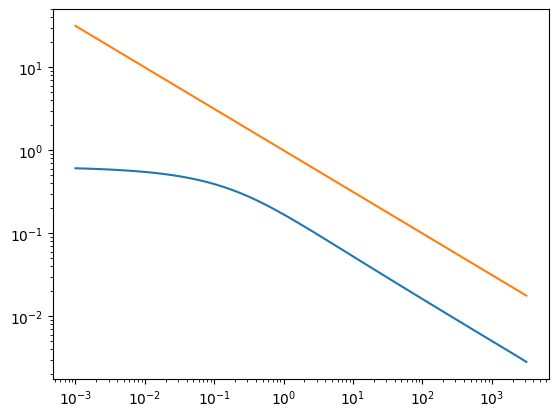

In [57]:
plot(taus,rhos)
plot(taus,taus**(-1/2))
loglog()

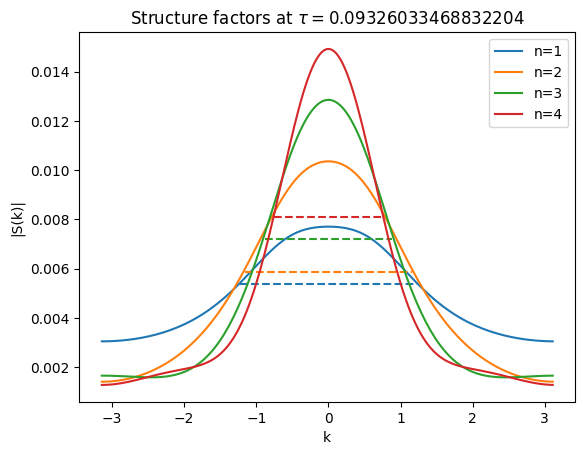

In [79]:
plt.figure()
j = 30

for idx in range(4):
    y = np.abs(s_kn[idx][j])
    y= y/sum(y)
    line, = plt.plot(k, y, label=f"n={idx+1}")
    color = line.get_color()

    # --- FWHM using custom definition ---
    ymin, ymax = np.min(y), np.max(y)
    half = ymin + 0.5 * (ymax - ymin)
    mask = y >= half
    if np.any(mask):
        k_left = k[np.argmax(mask)]
        k_right = k[::-1][np.argmax(mask[::-1])]
        plt.hlines(half, -abs(k_left), abs(k_right),
                   color=color, linestyle="--")

plt.title(rf"Structure factors at $\tau={taus[j]}$")
plt.legend()
plt.xlabel("k")
plt.ylabel("|S(k)|")
plt.show()

In [48]:
# def fwhm(x, y):
#     y = np.abs(y)
#     half = np.max(y) / 2.0
#     idx = np.where(np.diff(np.sign(y - half)))[0]
#     if len(idx) >= 2:
#         return x[idx[-1]] - x[idx[0]]
#     return np.nan
def fwhm(x, y):
    y = np.abs(y)
    ymin, ymax = np.min(y), np.max(y)
    half = ymin + 0.5 * (ymax - ymin)  # midpoint between min and max
    idx = np.where(np.diff(np.sign(y - half)))[0]
    if len(idx) >= 2:
        return x[idx[-1]] - x[idx[0]]
    return np.nan
ns = [1,2,3,4]

In [49]:
k_n = [ array([fwhm(k,abs(s_kn[n-1][j])) for j in range(len(taus))]) for n in ns]

In [50]:
k_n[0]

array([3.11017673, 3.11017673, 3.11017673, 3.11017673, 3.11017673,
       3.11017673, 3.11017673, 3.11017673, 3.11017673, 3.11017673,
       3.11017673, 3.04734487, 3.04734487, 3.04734487, 3.04734487,
       3.04734487, 2.98451302, 2.98451302, 2.98451302, 2.92168117,
       2.92168117, 2.85884931, 2.85884931, 2.79601746, 2.79601746,
       2.73318561, 2.67035376, 2.67035376, 2.6075219 , 2.54469005,
       2.4818582 , 2.41902634, 2.35619449, 2.29336264, 2.23053078,
       2.10486708, 2.04203522, 1.97920337, 1.91637152, 1.85353967,
       1.72787596, 1.66504411, 1.60221225, 1.47654855, 1.41371669,
       1.35088484, 1.28805299, 1.22522113, 1.16238928, 1.09955743,
       1.03672558, 0.97389372, 0.91106187, 0.84823002, 0.78539816,
       0.72256631, 0.65973446, 0.65973446, 0.5969026 , 0.53407075,
       0.53407075, 0.4712389 , 0.4712389 , 0.40840704, 0.40840704,
       0.34557519, 0.34557519, 0.34557519, 0.28274334, 0.28274334,
       0.28274334, 0.21991149, 0.21991149, 0.21991149, 0.21991

[]

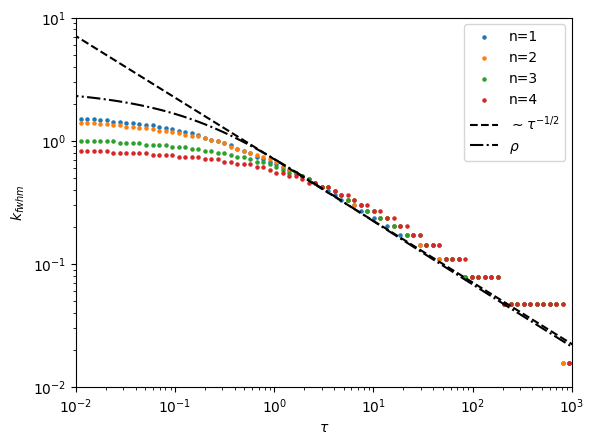

In [78]:
for n,kr in zip(ns,k_n[:4]):
    scatter(taus,(kr/2),s=5,label=f"n={n}")
plot(taus,1/(sqrt(2*taus)),"--k",label=r"$\sim \tau^{-1/2}$") 
plot(taus,4.2*rhos,"-.k",label=r"$\rho$")
ylabel(r"$k_{fwhm}$")
xlim(10e-3,10e2)
ylim(10e-3,10e0)
xlabel(r"$\tau$")
legend()
loglog()

[]

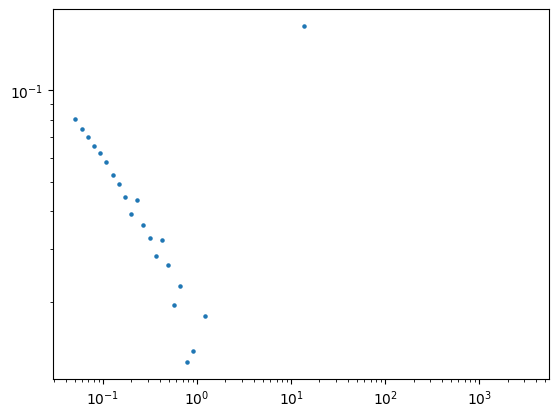

In [19]:

scatter(taus,abs(1/k_n[0]/2-1/(k_n[1])/2),s=5)

#xlim(10e-3,10e1)
loglog()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
[]